In [5]:
import sys
!{sys.executable} -m pip install pandas matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------------------------------- ---- 8.7/9.9 MB 41.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 38.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 52.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 41.3 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   -------------------------------------- - 12.1/12.4 MB 57.8 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 46.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 49.8 MB/s  0:00:00

   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\billo\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [10]:
import concurrent.interpreters as interpreters
import threading
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import sys
print(f"Version: {sys.version}")
print(f"Path: {sys.executable}")


Version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Path: C:\Users\billo\AppData\Local\Python\pythoncore-3.14-64\python.exe


🚀 Launched G1 sidecar...
🚀 Launched G2 sidecar...
🚀 Launched G3 sidecar...
🚀 Launched G4 sidecar...
--- NIPO Scaled Orchestrator: 4 Nodes Active ---
Time: 0.0s | Cluster Power: 1411.88W | NORMAL      
[DANGER] Total Power 2805.45W exceeds ceiling!
Time: 0.1s | Cluster Power: 2805.45W | THROTTLED      
[SAFE] Power stabilized at 1767.10W. Resuming...
Time: 0.1s | Cluster Power: 1767.10W | NORMAL      
[DANGER] Total Power 2796.84W exceeds ceiling!
Time: 0.2s | Cluster Power: 2796.84W | THROTTLED      
[SAFE] Power stabilized at 1803.11W. Resuming...
Time: 0.2s | Cluster Power: 1803.11W | NORMAL      
[DANGER] Total Power 2811.09W exceeds ceiling!
Time: 0.3s | Cluster Power: 2811.09W | THROTTLED      
[SAFE] Power stabilized at 1803.31W. Resuming...
Time: 0.3s | Cluster Power: 1803.31W | NORMAL      
[DANGER] Total Power 2798.30W exceeds ceiling!
Time: 0.4s | Cluster Power: 2798.30W | THROTTLED      
[SAFE] Power stabilized at 1793.00W. Resuming...
Time: 0.4s | Cluster Power: 1793.00W | 

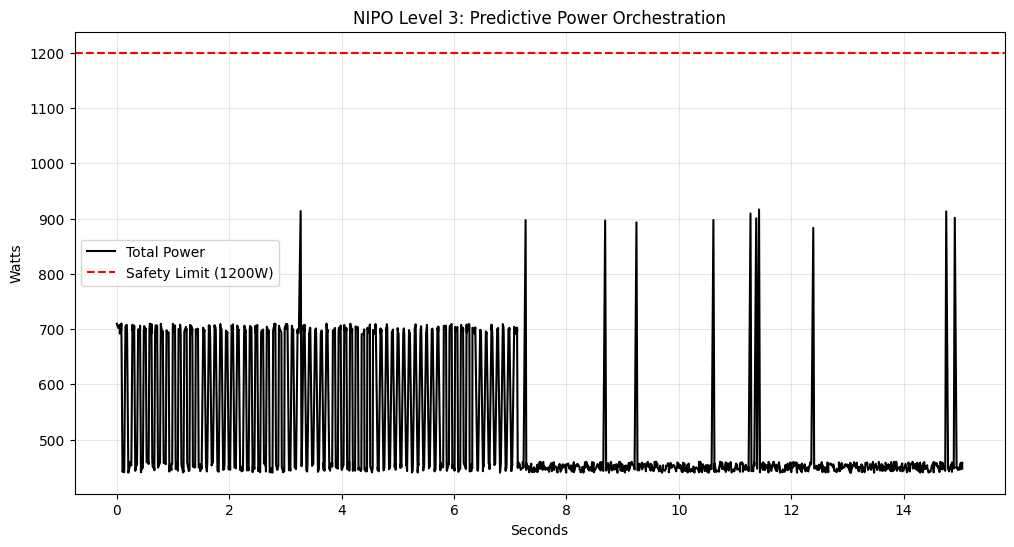

--- NIPO Level 3 Simulation Active (15s) ---
Time: 15.0s | Power: 901.53W | THROTTLED      
Simulation Complete. Generating Graph...


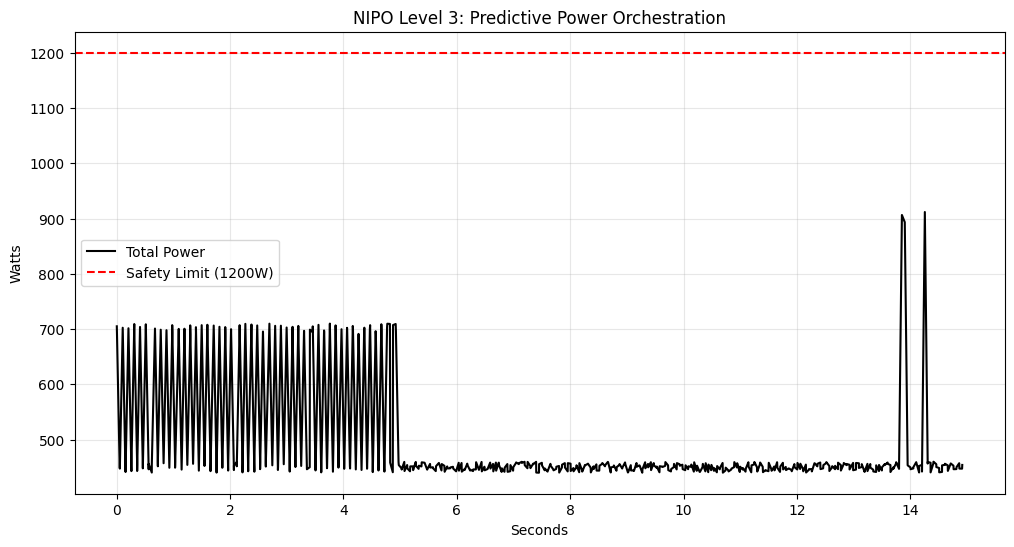

In [16]:
# --- 1. ADAPTIVE PREDICTOR ---
# CITATION: Logic based on "Predictive Power Shaping" (NVIDIA, 2026)
class AdaptivePredictor:
    def __init__(self, alpha=0.2):
        self.last_spike_time = time.time()
        self.current_interval = 0.1 # Start with 100ms estimate
        self.alpha = alpha

    def update(self, current_power):
        # We define a spike as any draw over 600W
        if current_power > 600:
            now = time.time()
            new_interval = now - self.last_spike_time
            # Update the rhythm estimate using a moving average
            self.current_interval = (self.current_interval * (1 - self.alpha)) + (new_interval * self.alpha)
            self.last_spike_time = now
            return True
        return False

    def time_until_next_spike(self):
        elapsed = time.time() - self.last_spike_time
        return max(0, self.current_interval - elapsed)

# --- 2. GPU NODE SIMULATOR ---
# This function runs inside an isolated subinterpreter
def run_gpu_node(input_q, output_q, name):
    import time, random
    import concurrent.interpreters as interpreters
    
    precision_mode = "HIGH" 
    while True:
        # Check for control signals like THROTTLE or RESUME
        if not input_q.empty():
            msg = input_q.get()
            if msg == "THROTTLE": precision_mode = "LOW"
            elif msg == "RESUME": precision_mode = "HIGH"
        
        # Power Scaling: HIGH=700W (BF16), LOW=450W (FP8)
        base = 700.0 if precision_mode == "HIGH" else 450.0
        current_w = base + random.uniform(-10, 10)
        
        # Send data back to the central orchestrator
        output_q.put({
            "node": name, 
            "power": current_w, 
            "mode": precision_mode, 
            "timestamp": time.time()
        })
        time.sleep(0.05)

# --- 3. VISUALIZATION ENGINE ---
def plot_results(history):
    if not history:
        print("No telemetry data collected.")
        return
        
    df = pd.DataFrame(history)
    # Group data by time to see the total cluster power
    df_total = df.groupby('timestamp')['power'].sum().reset_index()
    
    plt.figure(figsize=(12, 6))
    plt.plot(df_total['timestamp'] - df_total['timestamp'].min(), df_total['power'], color='black', label='Total Power')
    plt.axhline(y=1200, color='red', linestyle='--', label='Safety Limit (1200W)')
    plt.fill_between(df_total['timestamp'] - df_total['timestamp'].min(), 1200, df_total['power'], 
                     where=(df_total['power'] > 1200), color='red', alpha=0.3)
    
    plt.title("NIPO Level 3: Predictive Power Orchestration")
    plt.xlabel("Seconds")
    plt.ylabel("Watts")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 4. THE MAIN ORCHESTRATOR ---
"""
def run_nipo_predictive(duration_sec=15):
    telemetry_history = []
    predictor = AdaptivePredictor()
    
    # Setup communication channels
    ctrl_a, ctrl_b = interpreters.create_queue(), interpreters.create_queue()
    telemetry_q = interpreters.create_queue()
    sidecar_a, sidecar_b = interpreters.create(), interpreters.create()
    
    # Launch subinterpreters in background threads
    threading.Thread(target=sidecar_a.call, args=(run_gpu_node, ctrl_a, telemetry_q, "Node_A"), daemon=True).start()
    threading.Thread(target=sidecar_b.call, args=(run_gpu_node, ctrl_b, telemetry_q, "Node_B"), daemon=True).start()

    CRITICAL_CEILING, RECOVERY_THRESHOLD = 1200.0, 950.0 
    is_throttled = False
    start_time = time.time()

    print(f"--- NIPO Level 3 Simulation Active ({duration_sec}s) ---")
    while time.time() - start_time < duration_sec:
        node_powers = {}
        while not telemetry_q.empty():
            data = telemetry_q.get()
            node_powers[data['node']] = data['power']
            telemetry_history.append(data)
            if data['node'] == "Node_A": predictor.update(data['power'])

        total_power = sum(node_powers.values())
        
        if total_power > 0:
            status = "THROTTLED" if is_throttled else "NORMAL"
            print(f"Time: {time.time() - start_time:.1f}s | Power: {total_power:.2f}W | {status}      ", end='\r', flush=True)

        # Actuation logic based on NVIDIA 2026 standards
        if total_power > CRITICAL_CEILING and not is_throttled:
            ctrl_a.put("THROTTLE"); ctrl_b.put("THROTTLE")
            is_throttled = True
        elif is_throttled and total_power < RECOVERY_THRESHOLD:
            if predictor.time_until_next_spike() > 0.04:
                ctrl_a.put("RESUME"); ctrl_b.put("RESUME")
                is_throttled = False
        
        time.sleep(0.05)
    
    print("\nSimulation Complete. Generating Graph...")
    plot_results(telemetry_history)
    
    # --- CHANGE 1: Return the data so other cells can use it ---
    return telemetry_history 
"""
# --- Cell 4: SCALABLE MULTI-NODE ORCHESTRATOR ---

def run_nipo_scaled(node_names=["Node_1", "Node_2", "Node_3", "Node_4"], duration_sec=15):
    telemetry_history = []
    predictor = AdaptivePredictor()
    
    # 1. Dynamic Resource Allocation
    # We create a dictionary of control queues for N nodes
    ctrl_queues = {name: interpreters.create_queue() for name in node_names}
    telemetry_q = interpreters.create_queue()
    
    # 2. Parallel Launch Loop
    for name in node_names:
        sidecar = interpreters.create()
        threading.Thread(
            target=sidecar.call, 
            args=(run_gpu_node, ctrl_queues[name], telemetry_q, name), 
            daemon=True
        ).start()
        print(f" Launched {name} sidecar...")

    # 3. Scaled Thresholds (Adjusted for N nodes)
    # Example: 600W limit per node in the cluster
    CRITICAL_CEILING = len(node_names) * 600.0   
    RECOVERY_THRESHOLD = len(node_names) * 475.0 
    is_throttled = False
    start_time = time.time()

    print(f"--- NIPO Scaled Orchestrator: {len(node_names)} Nodes Active ---")
    
    while time.time() - start_time < duration_sec:
        node_powers = {}
        # Drain the central telemetry queue
        while not telemetry_q.empty():
            data = telemetry_q.get()
            node_powers[data['node']] = data['power']
            telemetry_history.append(data)
            # Use the first node as the phase-lock reference
            if data['node'] == node_names[0]: predictor.update(data['power'])

        total_power = sum(node_powers.values())
        
        # 4. Global Actuation
        if total_power > CRITICAL_CEILING and not is_throttled:
            print(f"\n[DANGER] Total Power {total_power:.2f}W exceeds ceiling!")
            for q in ctrl_queues.values(): q.put("THROTTLE")
            is_throttled = True
        
        elif is_throttled and total_power < RECOVERY_THRESHOLD:
            if predictor.time_until_next_spike() > 0.04:
                print(f"\n[SAFE] Power stabilized at {total_power:.2f}W. Resuming...")
                for q in ctrl_queues.values(): q.put("RESUME")
                is_throttled = False
        
        # Live status update
        if total_power > 0:
            status = "THROTTLED" if is_throttled else "NORMAL"
            print(f"Time: {time.time()-start_time:.1f}s | Cluster Power: {total_power:.2f}W | {status}      ", end='\r', flush=True)
            
        time.sleep(0.05)
    
    print("\nSimulation Complete.")
    plot_results(telemetry_history)
    return telemetry_history

# Execute with 4 nodes
if __name__ == "__main__":
    simulation_data = run_nipo_scaled(node_names=["G1", "G2", "G3", "G4"], duration_sec=15)

    

# Run the simulation
if __name__ == "__main__":
    simulation_data = run_nipo_predictive(duration_sec=15)

In [15]:


def save_nipo_results(history, filename="nipo_telemetry_log.csv"):
    if not history:
        print("No data found. Please ensure Cell 4 has finished running.")
        return
    
    # Use Pandas to structure the raw dictionaries
    df = pd.DataFrame(history)
    
    # Export to the same folder as your notebook
    df.to_csv(filename, index=False)
    
    print(f"✅ Export Successful: {filename}")
    print(f"Total Data Points Captured: {len(df)}")
    print("You can now open this file in Excel to view the millisecond-level power logs.")

save_nipo_results(simulation_data)

✅ Export Successful: nipo_telemetry_log.csv
Total Data Points Captured: 584
You can now open this file in Excel to view the millisecond-level power logs.
